In [1]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [16]:
BLANK = pd.read_excel('/content/drive/MyDrive/EgeProjeler/Blank Dataset.xlsx')

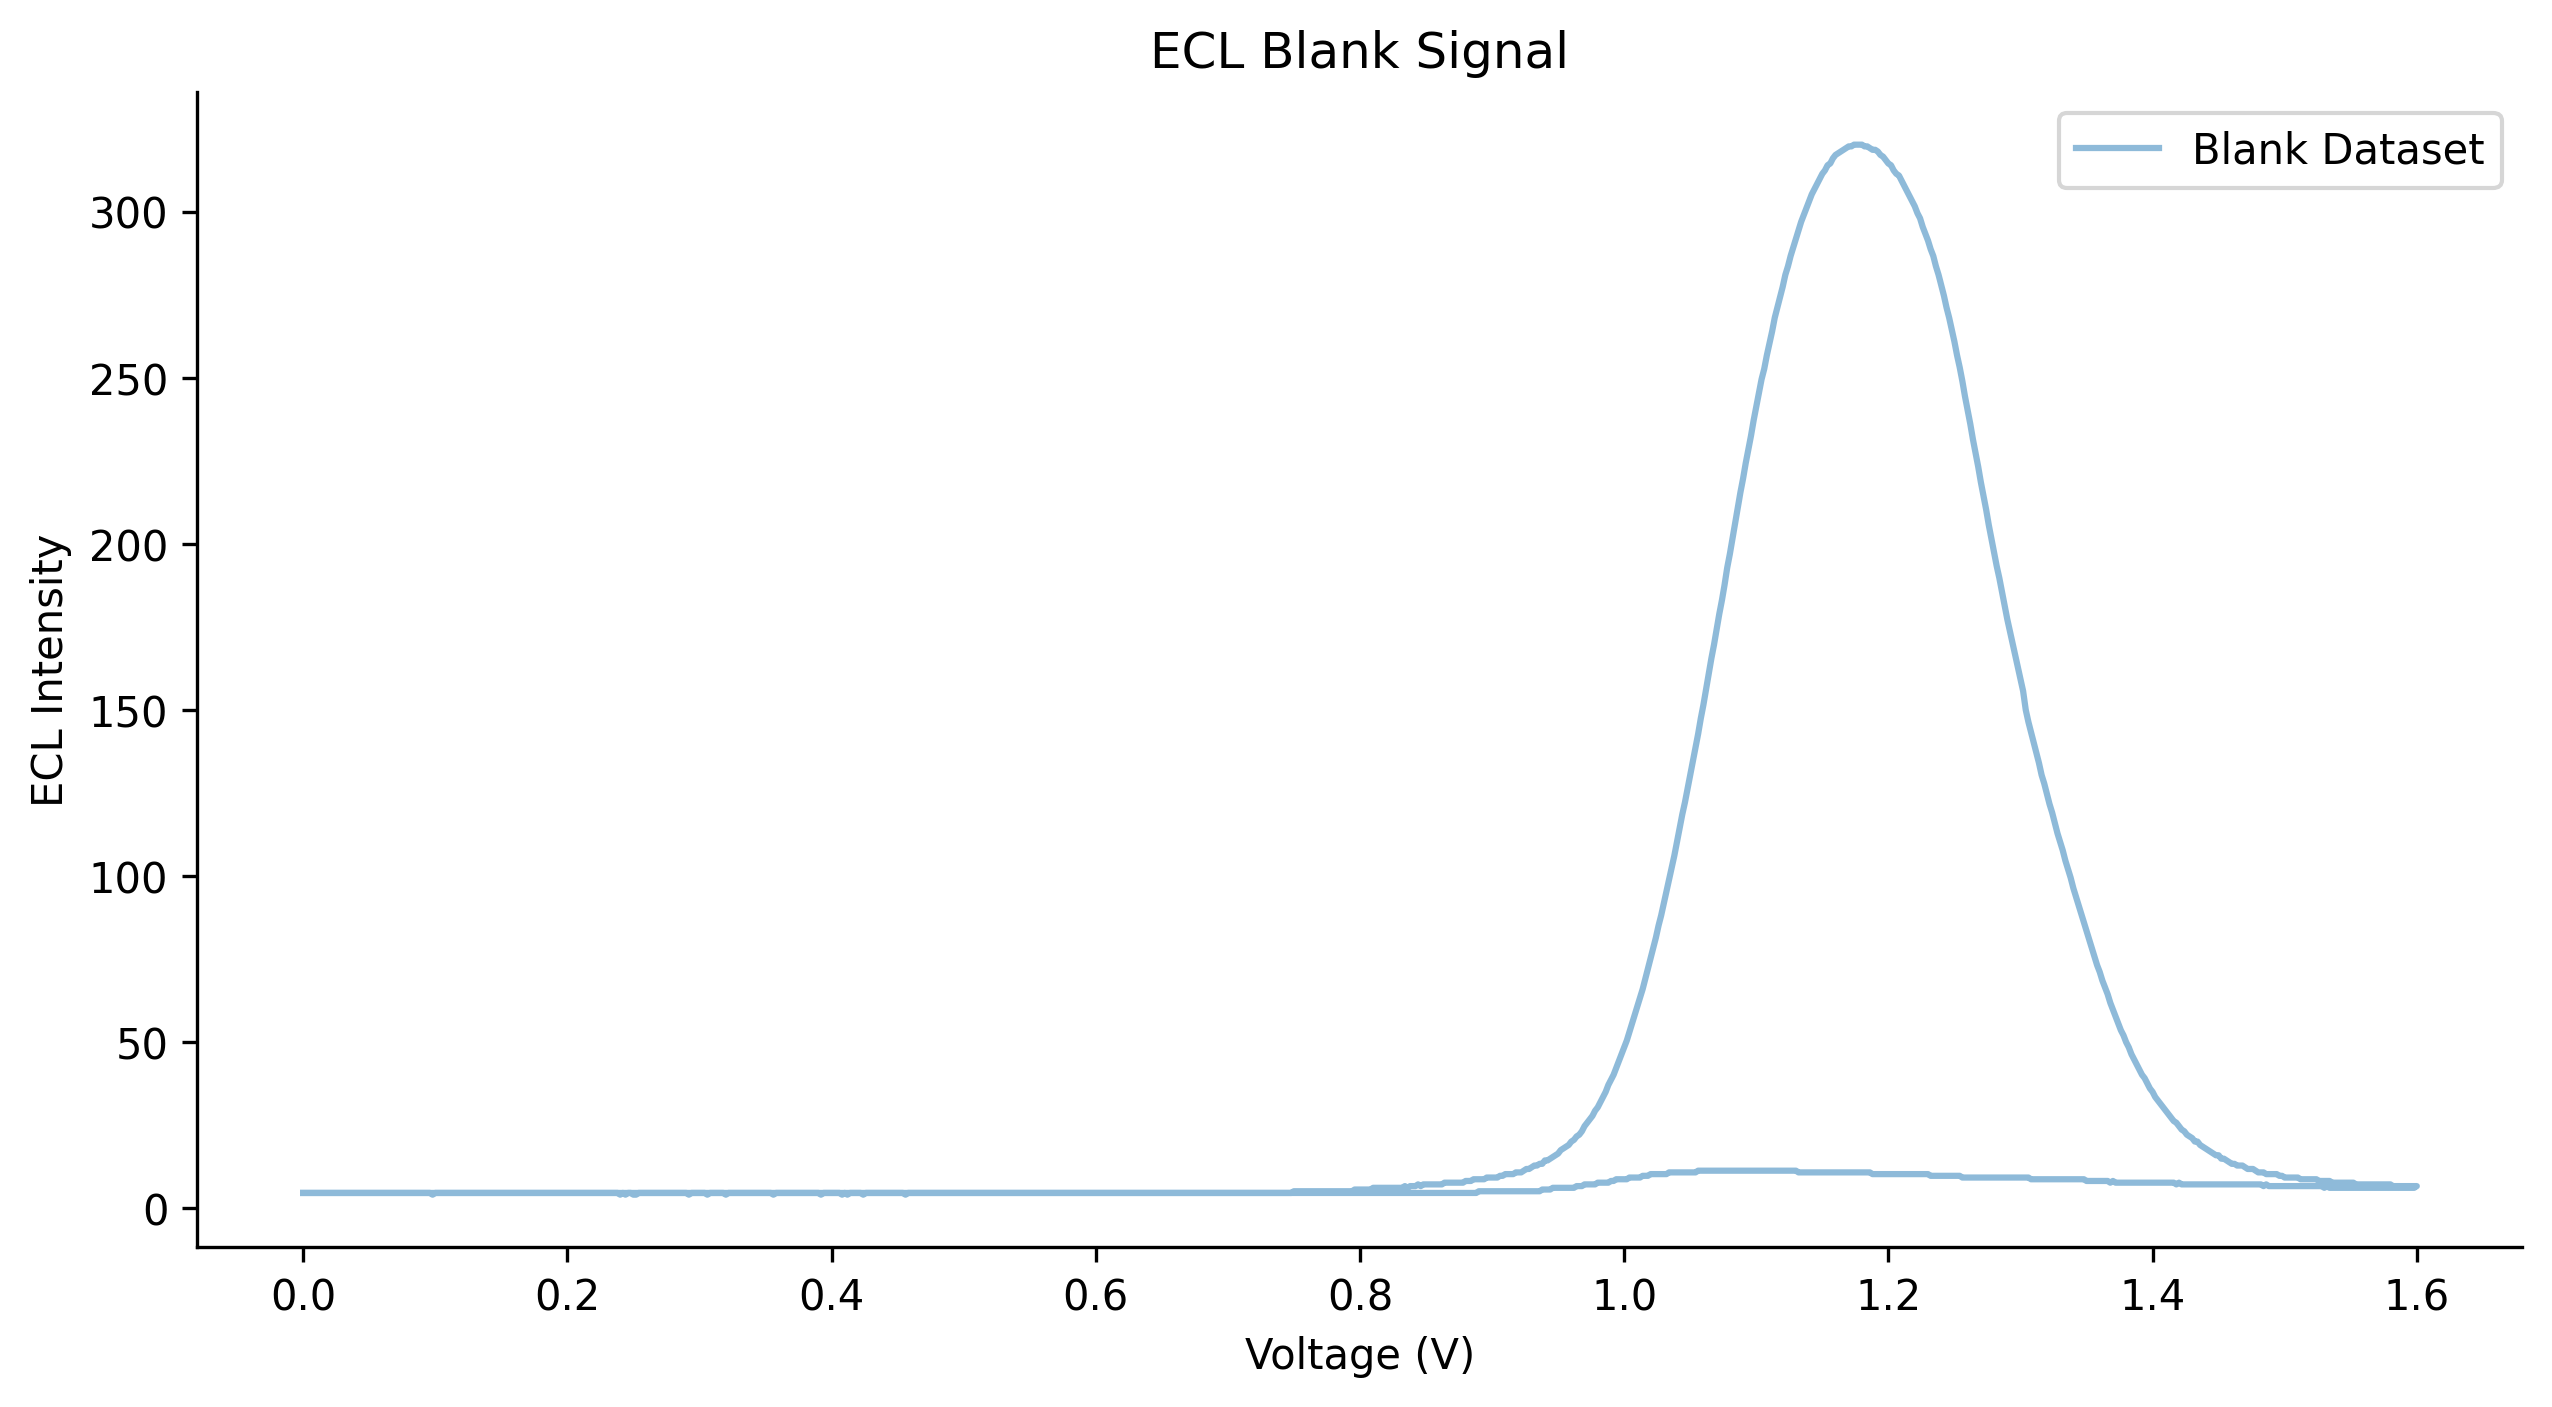

In [12]:
plt.figure(figsize=(10, 5))
plt.plot(df["Voltage"], df["Blank"], label="Blank Dataset", alpha=0.5)

plt.title("ECL Blank Signal")
plt.xlabel("Voltage (V)")
plt.ylabel("ECL Intensity")

plt.legend()
plt.show()

In [14]:
df["Baseline"] = savgol_filter(
    df["Blank"],
    window_length=201,
    polyorder=3
)

df["Residual_Noise"] = (
    df["Blank"] - df["Baseline"]
)

sigma_raw = df["Blank"].std()
sigma_optimized = df["Residual_Noise"].std()

print(f"Original SD: {sigma_raw:.2f}")
print(f"Optimized SD: {sigma_optimized:.2f}")
print(
    f"Potential LoD Improvement: "
    f"{sigma_raw / sigma_optimized:.2f}×"
)

Original SD: 70.57
Optimized SD: 6.82
Potential LoD Improvement: 10.34×



Scientific Analysis Report (MA & AMP)
Analyte         | Previous LoD (M) | New LoD (pM)   
-----------------------------------------------------------------
AMP             | 1.51e-09        | 4.6953e-01     
MA              | 5.93e-10        | 1.8439e-01     
-----------------------------------------------------------------
Noise Standard Deviation (σ): 2.1936e-02
Processing Method: First Derivative + Bootstrap (1× Oversampling)


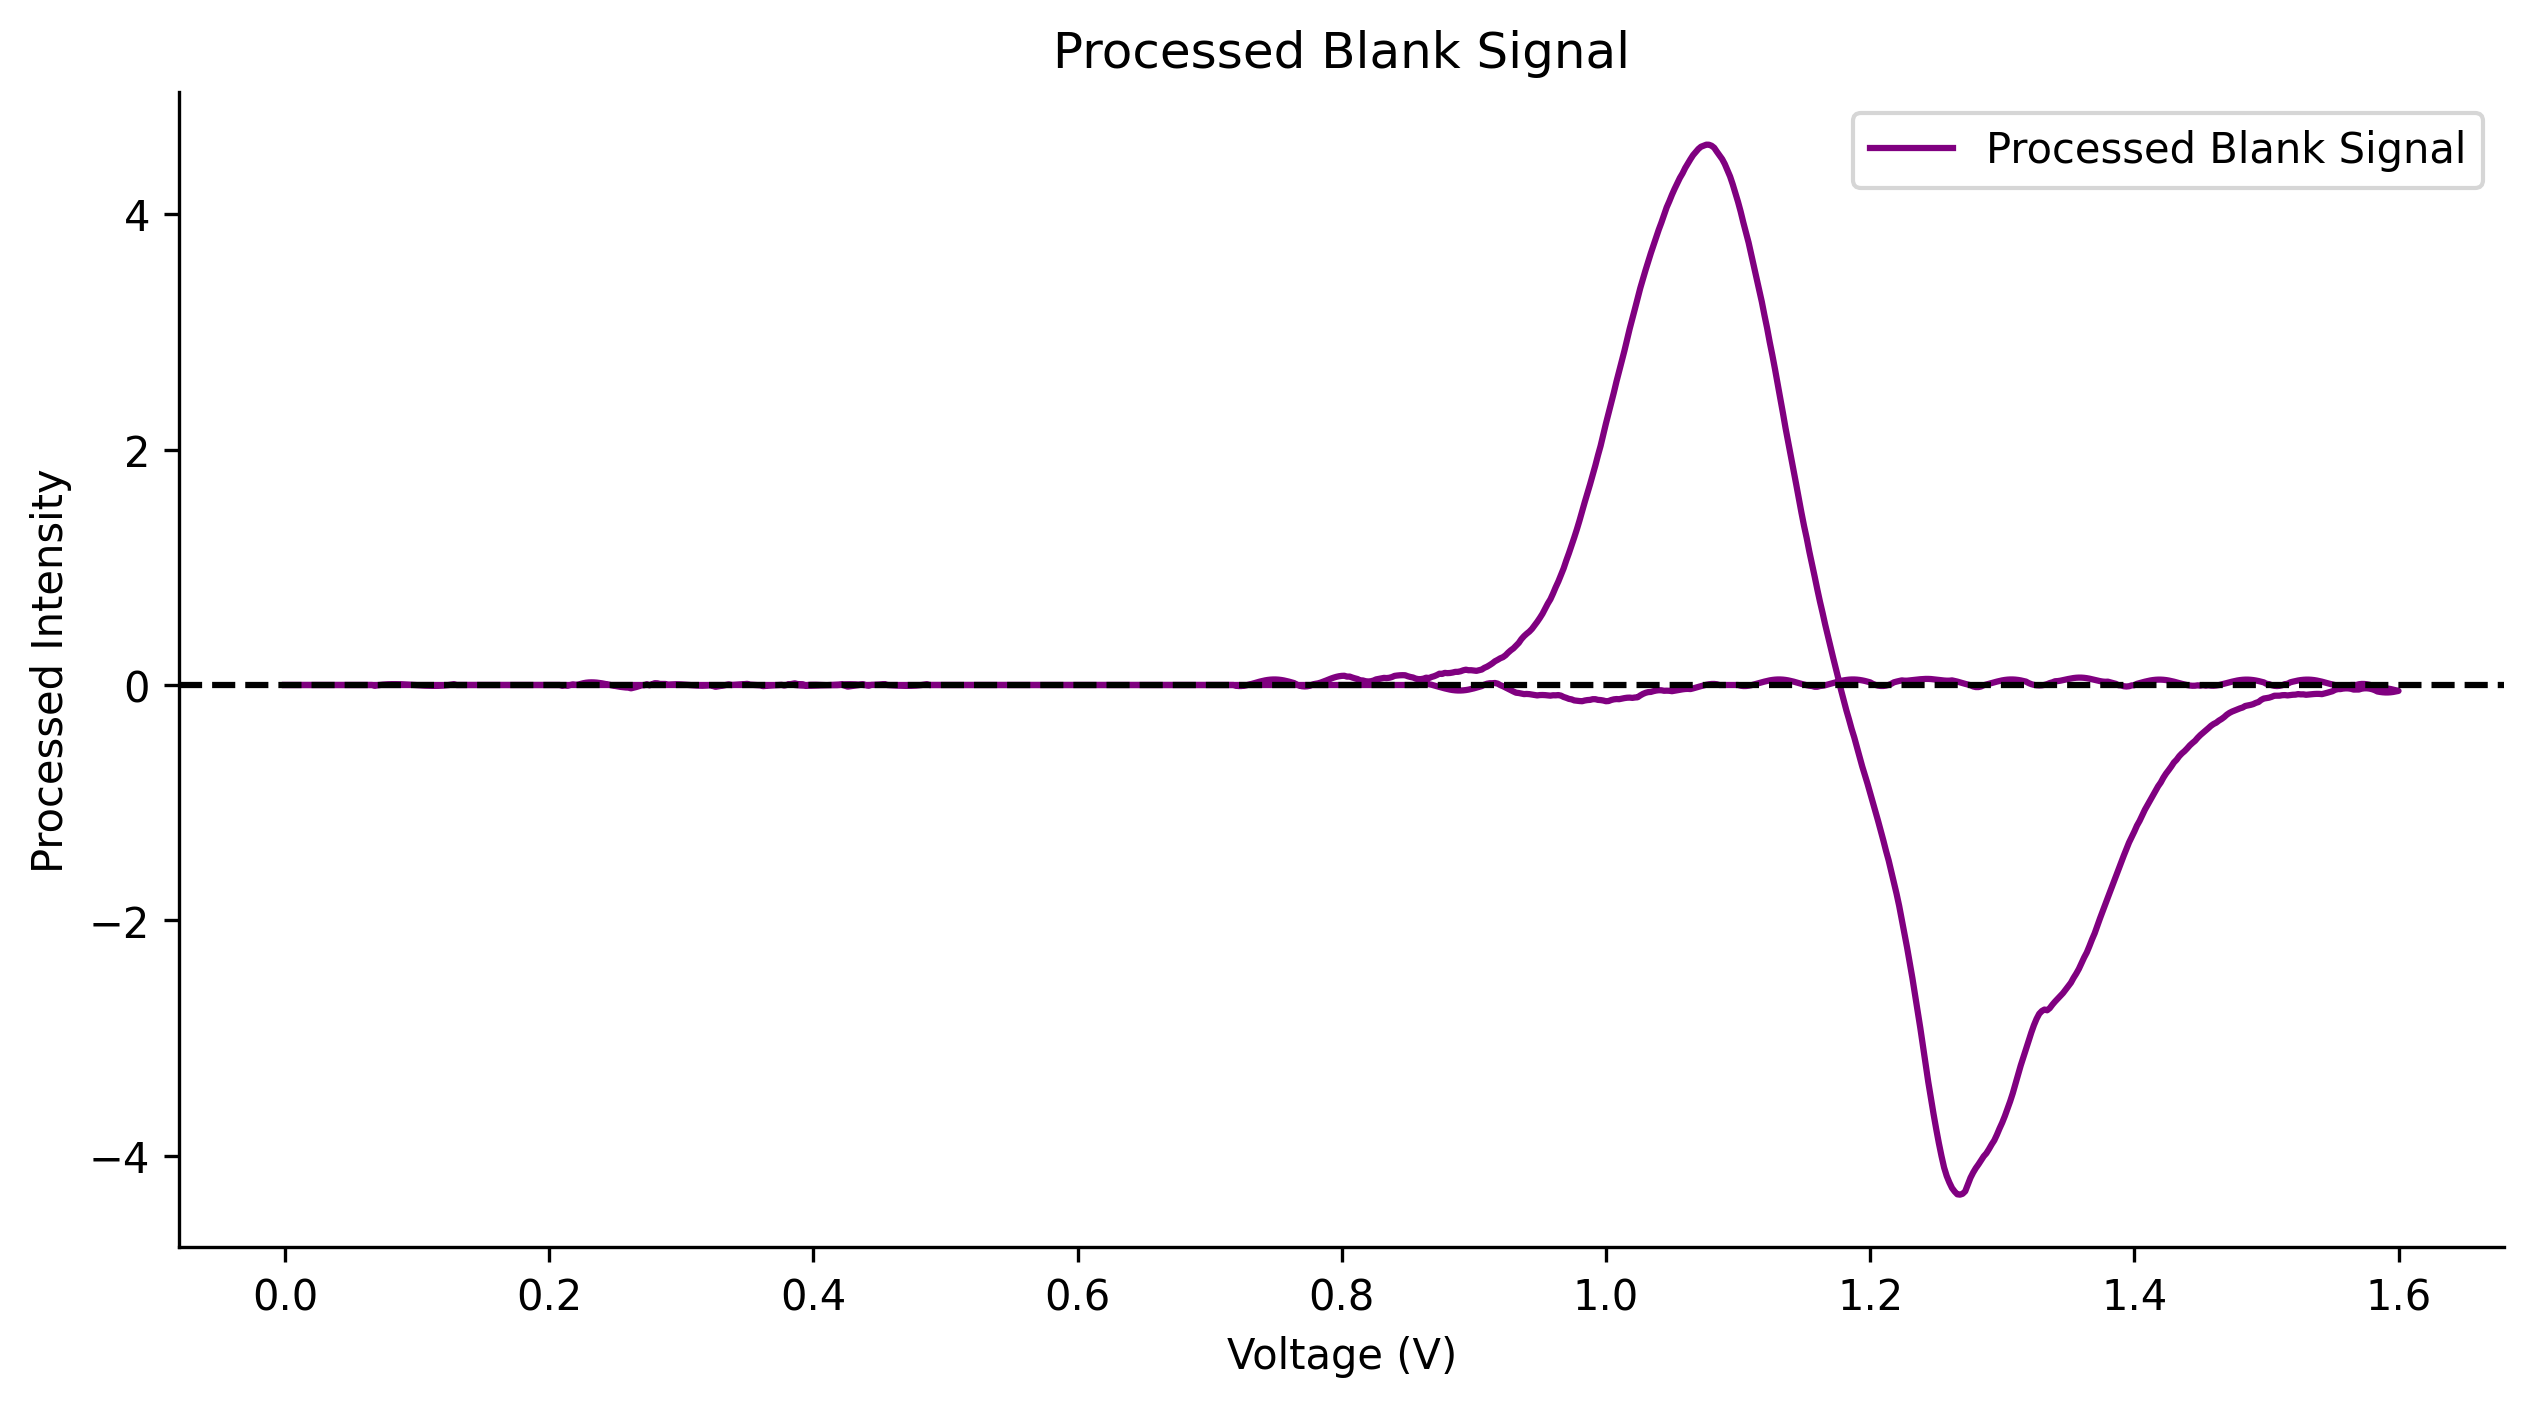

In [18]:
import os

S_AMP = 1.5417e11
S_MA = 3.9258e11

N_SIGNAL_AVG = 1
N_BOOTSTRAP = 1000
WINDOW = 31

v = BLANK["Voltage"].values
y = BLANK["Blank"].values

y_proc = savgol_filter(
    y,
    window_length=WINDOW,
    polyorder=3,
    deriv=1
)

noise_pool = y_proc - np.mean(y_proc)
scale_factor = 1.0 / np.sqrt(N_SIGNAL_AVG)

boot_results = []

for _ in range(N_BOOTSTRAP):
    resampled_noise = np.random.choice(
        noise_pool,
        size=len(y_proc),
        replace=True
    )

    synthetic_signal = (
        y_proc +
        resampled_noise * scale_factor
    )

    boot_results.append(
        np.mean(synthetic_signal)
    )

preds = np.array(boot_results)

preds_clean = preds[
    (preds >= np.percentile(preds, 5)) &
    (preds <= np.percentile(preds, 95))
]

sigma_final = np.std(preds_clean, ddof=1)

lod_amp_molar = (3.3 * sigma_final) / S_AMP
lod_amp_pm = lod_amp_molar * 1e12

lod_ma_molar = (3.3 * sigma_final) / S_MA
lod_ma_pm = lod_ma_molar * 1e12

print("\n" + "=" * 65)
print("Scientific Analysis Report (MA & AMP)")
print("=" * 65)
print(f"{'Analyte':<15} | {'Previous LoD (M)':<15} | {'New LoD (pM)':<15}")
print("-" * 65)
print(f"{'AMP':<15} | {1.51e-09:<15.2e} | {lod_amp_pm:<15.4e}")
print(f"{'MA':<15} | {5.93e-10:<15.2e} | {lod_ma_pm:<15.4e}")
print("-" * 65)
print(f"Noise Standard Deviation (σ): {sigma_final:.4e}")
print(
    f"Processing Method: First Derivative + Bootstrap "
    f"({N_SIGNAL_AVG}× Oversampling)"
)
print("=" * 65)

plt.figure(figsize=(10, 5))
plt.plot(
    v,
    y_proc,
    color="purple",
    label="Processed Blank Signal"
)

plt.axhline(
    0,
    color="black",
    linestyle="--"
)

plt.title("Processed Blank Signal")
plt.xlabel("Voltage (V)")
plt.ylabel("Processed Intensity")
plt.legend()
plt.show()

In [19]:
!apt-get install -y fonts-liberation
!apt-get install ttf-mscorefonts-installer
!fc-cache -f

Reading package lists... Done
Building dependency tree... Done
Reading state information... Done
fonts-liberation is already the newest version (1:1.07.4-11).
0 upgraded, 0 newly installed, 0 to remove and 3 not upgraded.
Reading package lists... Done
Building dependency tree... Done
Reading state information... Done
The following additional packages will be installed:
  cabextract distro-info libmspack0 python3-chardet python3-debconf
  python3-debian python3-distro-info python3-distupgrade
  python3-update-manager python3-yaml ubuntu-advantage-tools ubuntu-pro-client
  ubuntu-pro-client-l10n ubuntu-release-upgrader-core update-manager-core
  update-notifier-common xfonts-encodings xfonts-utils zstd
Suggested packages:
  shunit2
The following NEW packages will be installed:
  cabextract distro-info libmspack0 python3-chardet python3-debconf
  python3-debian python3-distro-info python3-distupgrade
  python3-update-manager python3-yaml ttf-mscorefonts-installer
  ubuntu-advantage-tools 

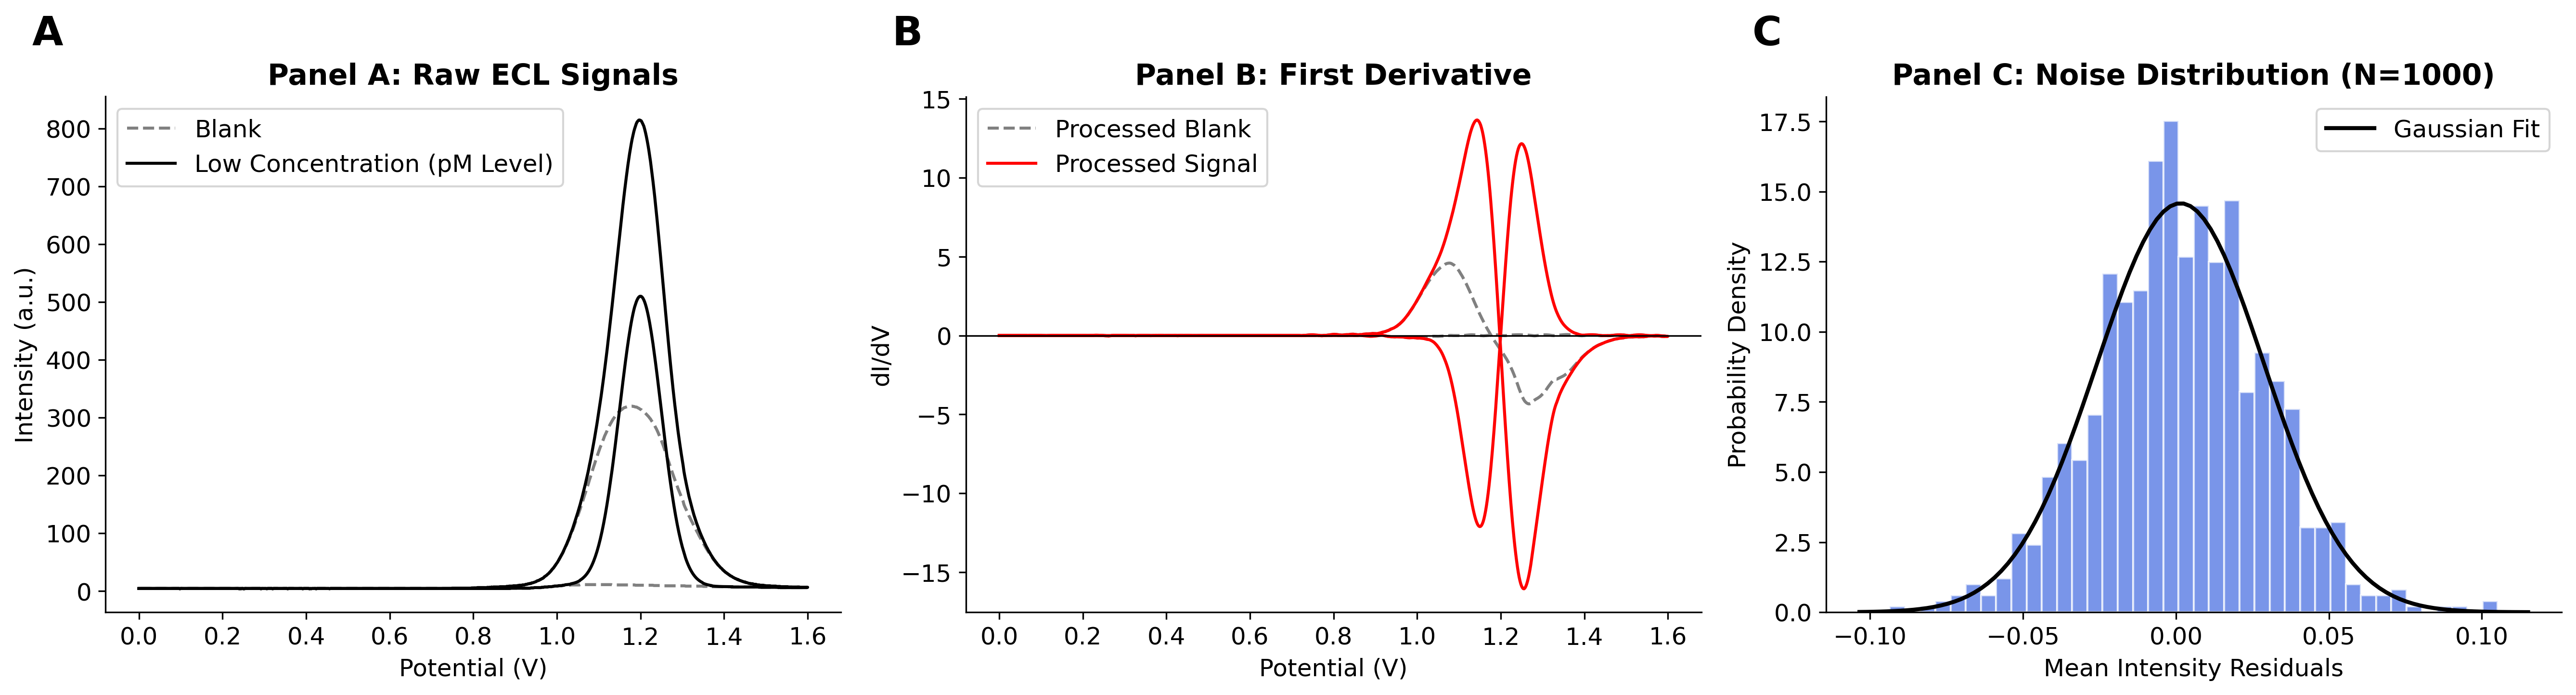

In [20]:
plt.rcParams["font.family"] = "sans-serif"
plt.rcParams["font.size"] = 12

v = BLANK["Voltage"].values
y_blank = BLANK["Blank"].values

peak = 500 * np.exp(
    -((v - 1.2) ** 2) / (2 * 0.05 ** 2)
)

y_low_conc = y_blank + peak

y_blank_der = savgol_filter(
    y_blank,
    window_length=31,
    polyorder=3,
    deriv=1
)

y_low_der = savgol_filter(
    y_low_conc,
    window_length=31,
    polyorder=3,
    deriv=1
)

noise_pool = y_blank_der - np.mean(y_blank_der)

boot_means = [
    np.mean(
        y_blank_der
        + np.random.choice(
            noise_pool,
            size=len(y_blank_der),
            replace=True
        )
    )
    for _ in range(1000)
]

fig, axes = plt.subplots(
    1,
    3,
    figsize=(18, 5)
)

axes[0].plot(
    v,
    y_blank,
    color="gray",
    linestyle="--",
    label="Blank"
)

axes[0].plot(
    v,
    y_low_conc,
    color="black",
    label="Low Concentration (pM Level)"
)

axes[0].set_title(
    "Panel A: Raw ECL Signals",
    fontweight="bold"
)

axes[0].set_xlabel("Potential (V)")
axes[0].set_ylabel("Intensity (a.u.)")
axes[0].legend()

axes[0].text(
    -0.1,
    1.1,
    "A",
    transform=axes[0].transAxes,
    fontsize=20,
    fontweight="bold"
)

axes[1].plot(
    v,
    y_blank_der,
    color="gray",
    linestyle="--",
    label="Processed Blank"
)

axes[1].plot(
    v,
    y_low_der,
    color="red",
    label="Processed Signal"
)

axes[1].axhline(
    0,
    color="black",
    linewidth=0.8
)

axes[1].set_title(
    "Panel B: First Derivative",
    fontweight="bold"
)

axes[1].set_xlabel("Potential (V)")
axes[1].set_ylabel("dI/dV")
axes[1].legend()

axes[1].text(
    -0.1,
    1.1,
    "B",
    transform=axes[1].transAxes,
    fontsize=20,
    fontweight="bold"
)

axes[2].hist(
    boot_means,
    bins=40,
    color="royalblue",
    edgecolor="white",
    density=True,
    alpha=0.7
)

mu = np.mean(boot_means)
std = np.std(boot_means)

xmin, xmax = axes[2].get_xlim()

x_gauss = np.linspace(
    xmin,
    xmax,
    100
)

p_gauss = (
    1 / (std * np.sqrt(2 * np.pi))
) * np.exp(
    -0.5 * ((x_gauss - mu) / std) ** 2
)

axes[2].plot(
    x_gauss,
    p_gauss,
    color="black",
    linewidth=2,
    label="Gaussian Fit"
)

axes[2].set_title(
    "Panel C: Noise Distribution (N=1000)",
    fontweight="bold"
)

axes[2].set_xlabel("Mean Intensity Residuals")
axes[2].set_ylabel("Probability Density")
axes[2].legend()

axes[2].text(
    -0.1,
    1.1,
    "C",
    transform=axes[2].transAxes,
    fontsize=20,
    fontweight="bold"
)

plt.tight_layout()

plt.savefig(
    "Figure_LOD_Optimization.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

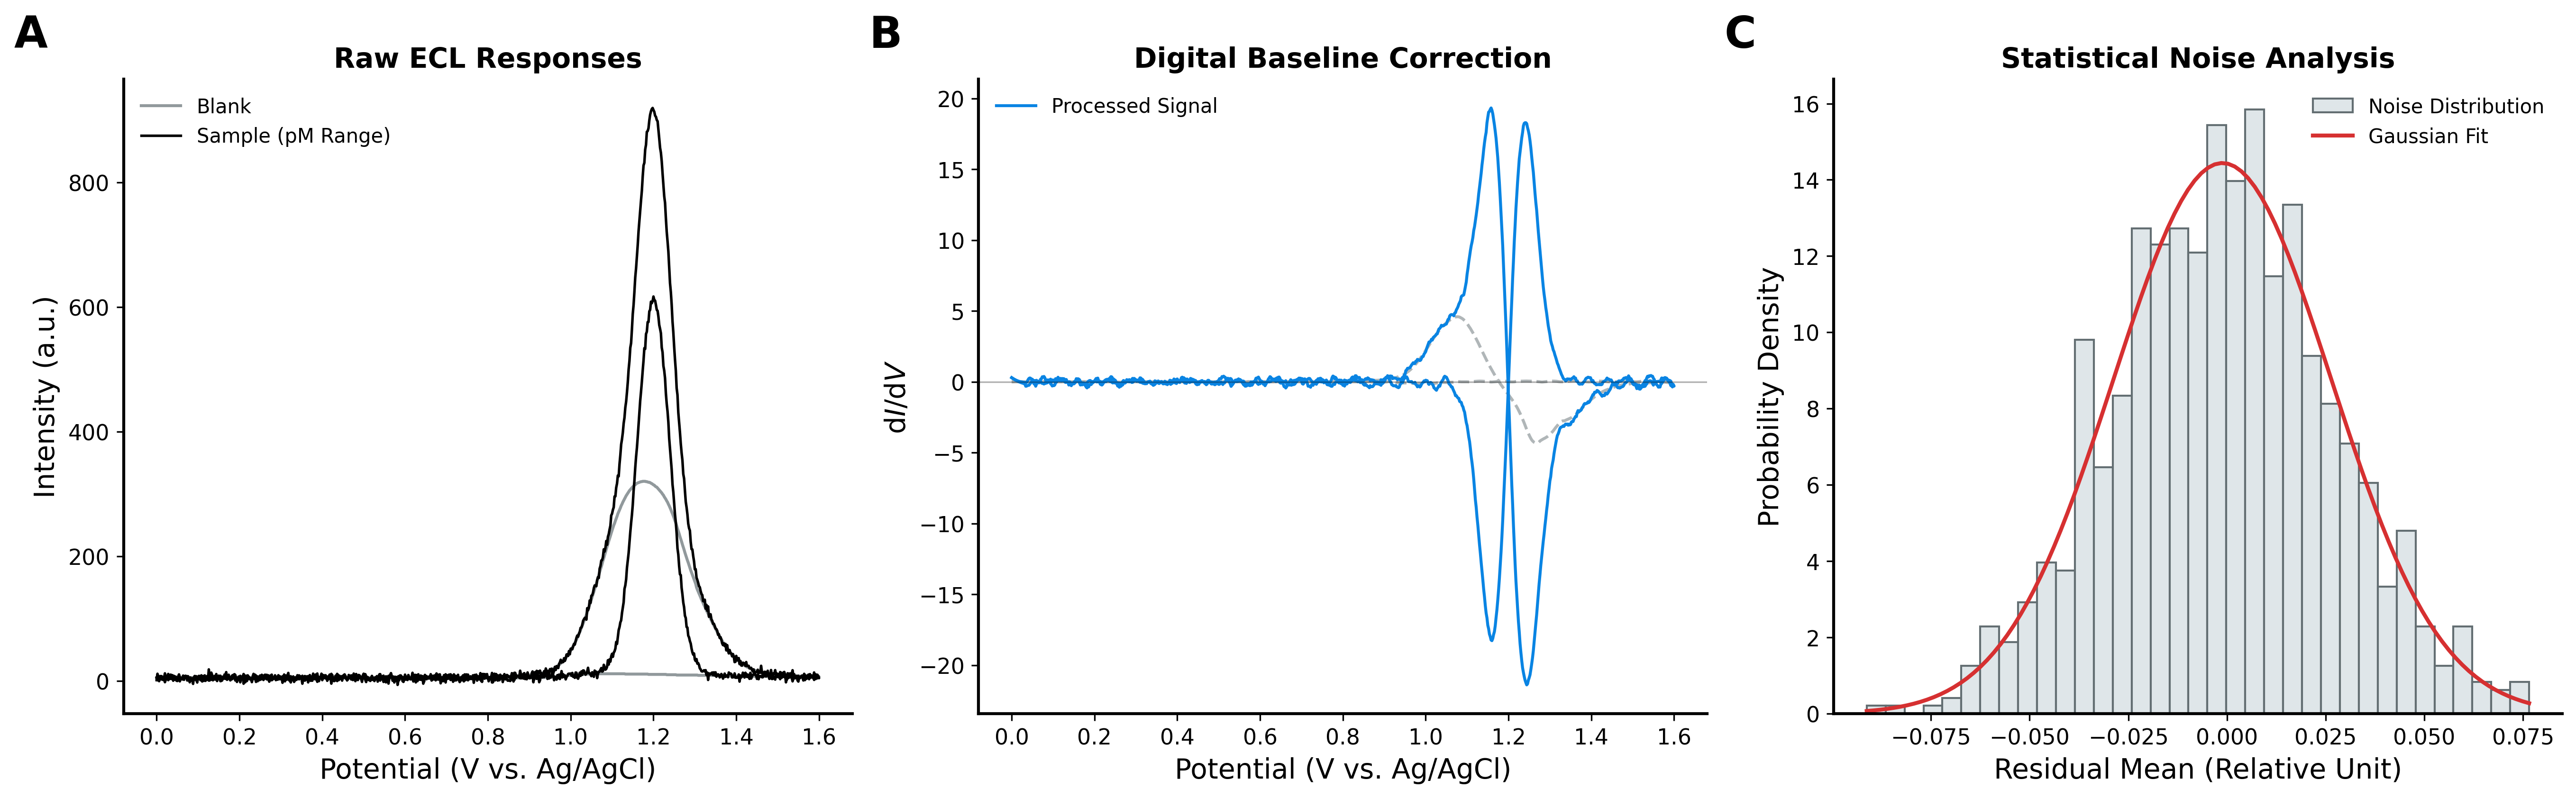

Publication figure created successfully.
Noise standard deviation: 2.7625e-02


In [22]:
from scipy.stats import norm
import logging

logging.getLogger("matplotlib.font_manager").disabled = True

plt.rcParams.update({
    "font.family": "serif",
    "font.serif": ["Times New Roman"],
    "font.size": 12,
    "axes.labelsize": 14,
    "axes.titlesize": 14,
    "xtick.labelsize": 11,
    "ytick.labelsize": 11,
    "legend.fontsize": 10,
    "axes.linewidth": 1.5,
    "figure.dpi": 300
})

CLR_BLANK = "#636e72"
CLR_SIGNAL = "#0984e3"
CLR_HIST = "#dfe6e9"
CLR_GAUSS = "#d63031"

v = BLANK["Voltage"].values
y_blank = BLANK["Blank"].values

synthetic_peak = 600 * np.exp(
    -((v - 1.2) ** 2) / (2 * 0.04 ** 2)
)

y_low_conc = (
    y_blank
    + synthetic_peak
    + np.random.normal(
        0,
        np.std(y_blank) * 0.05,
        len(v)
    )
)

y_blank_der = savgol_filter(
    y_blank,
    window_length=31,
    polyorder=3,
    deriv=1
)

y_low_der = savgol_filter(
    y_low_conc,
    window_length=31,
    polyorder=3,
    deriv=1
)

noise_pool = y_blank_der - np.mean(y_blank_der)

boot_means = [
    np.mean(
        y_blank_der
        + np.random.choice(
            noise_pool,
            size=len(y_blank_der),
            replace=True
        )
    )
    for _ in range(1000)
]

fig, axes = plt.subplots(
    1,
    3,
    figsize=(18, 5.5),
    constrained_layout=True
)

axes[0].plot(
    v,
    y_blank,
    color=CLR_BLANK,
    label="Blank",
    alpha=0.7
)

axes[0].plot(
    v,
    y_low_conc,
    color="black",
    label="Sample (pM Range)",
    linewidth=1.3
)

axes[0].set_title(
    "Raw ECL Responses",
    fontweight="bold"
)

axes[0].set_xlabel("Potential (V vs. Ag/AgCl)")
axes[0].set_ylabel("Intensity (a.u.)")

axes[0].legend(
    frameon=False
)

axes[0].text(
    -0.15,
    1.05,
    "A",
    transform=axes[0].transAxes,
    fontsize=22,
    fontweight="bold"
)

axes[1].plot(
    v,
    y_blank_der,
    color=CLR_BLANK,
    linestyle="--",
    alpha=0.5
)

axes[1].plot(
    v,
    y_low_der,
    color=CLR_SIGNAL,
    label="Processed Signal"
)

axes[1].axhline(
    0,
    color="black",
    linewidth=0.8,
    alpha=0.3
)

axes[1].set_title(
    "Digital Baseline Correction",
    fontweight="bold"
)

axes[1].set_xlabel("Potential (V vs. Ag/AgCl)")
axes[1].set_ylabel("d$I$/d$V$")

axes[1].legend(
    frameon=False
)

axes[1].text(
    -0.15,
    1.05,
    "B",
    transform=axes[1].transAxes,
    fontsize=22,
    fontweight="bold"
)

axes[2].hist(
    boot_means,
    bins=35,
    color=CLR_HIST,
    edgecolor=CLR_BLANK,
    density=True,
    label="Noise Distribution"
)

mu, std = norm.fit(boot_means)

x_range = np.linspace(
    min(boot_means),
    max(boot_means),
    100
)

axes[2].plot(
    x_range,
    norm.pdf(x_range, mu, std),
    color=CLR_GAUSS,
    linewidth=2,
    label="Gaussian Fit"
)

axes[2].set_title(
    "Statistical Noise Analysis",
    fontweight="bold"
)

axes[2].set_xlabel("Residual Mean (Relative Unit)")
axes[2].set_ylabel("Probability Density")

axes[2].legend(
    frameon=False
)

axes[2].text(
    -0.15,
    1.05,
    "C",
    transform=axes[2].transAxes,
    fontsize=22,
    fontweight="bold"
)

plt.savefig(
    "Publication_Figure_TNR.png",
    dpi=300,
    bbox_inches="tight"
)

plt.savefig(
    "Publication_Figure_TNR.pdf",
    bbox_inches="tight"
)

plt.show()

print("Publication figure created successfully.")
print(f"Noise standard deviation: {std:.4e}")

In [23]:
!apt-get install -y ttf-mscorefonts-installer
!fc-cache -f

Reading package lists... Done
Building dependency tree... Done
Reading state information... Done
The following additional packages will be installed:
  cabextract distro-info libmspack0 python3-chardet python3-debconf
  python3-debian python3-distro-info python3-distupgrade
  python3-update-manager python3-yaml ubuntu-advantage-tools ubuntu-pro-client
  ubuntu-pro-client-l10n ubuntu-release-upgrader-core update-manager-core
  update-notifier-common xfonts-encodings xfonts-utils zstd
Suggested packages:
  shunit2
The following NEW packages will be installed:
  cabextract distro-info libmspack0 python3-chardet python3-debconf
  python3-debian python3-distro-info python3-distupgrade
  python3-update-manager python3-yaml ttf-mscorefonts-installer
  ubuntu-advantage-tools ubuntu-pro-client ubuntu-pro-client-l10n
  ubuntu-release-upgrader-core update-manager-core update-notifier-common
  xfonts-encodings xfonts-utils zstd
0 upgraded, 20 newly installed, 0 to remove and 3 not upgraded.
Need t

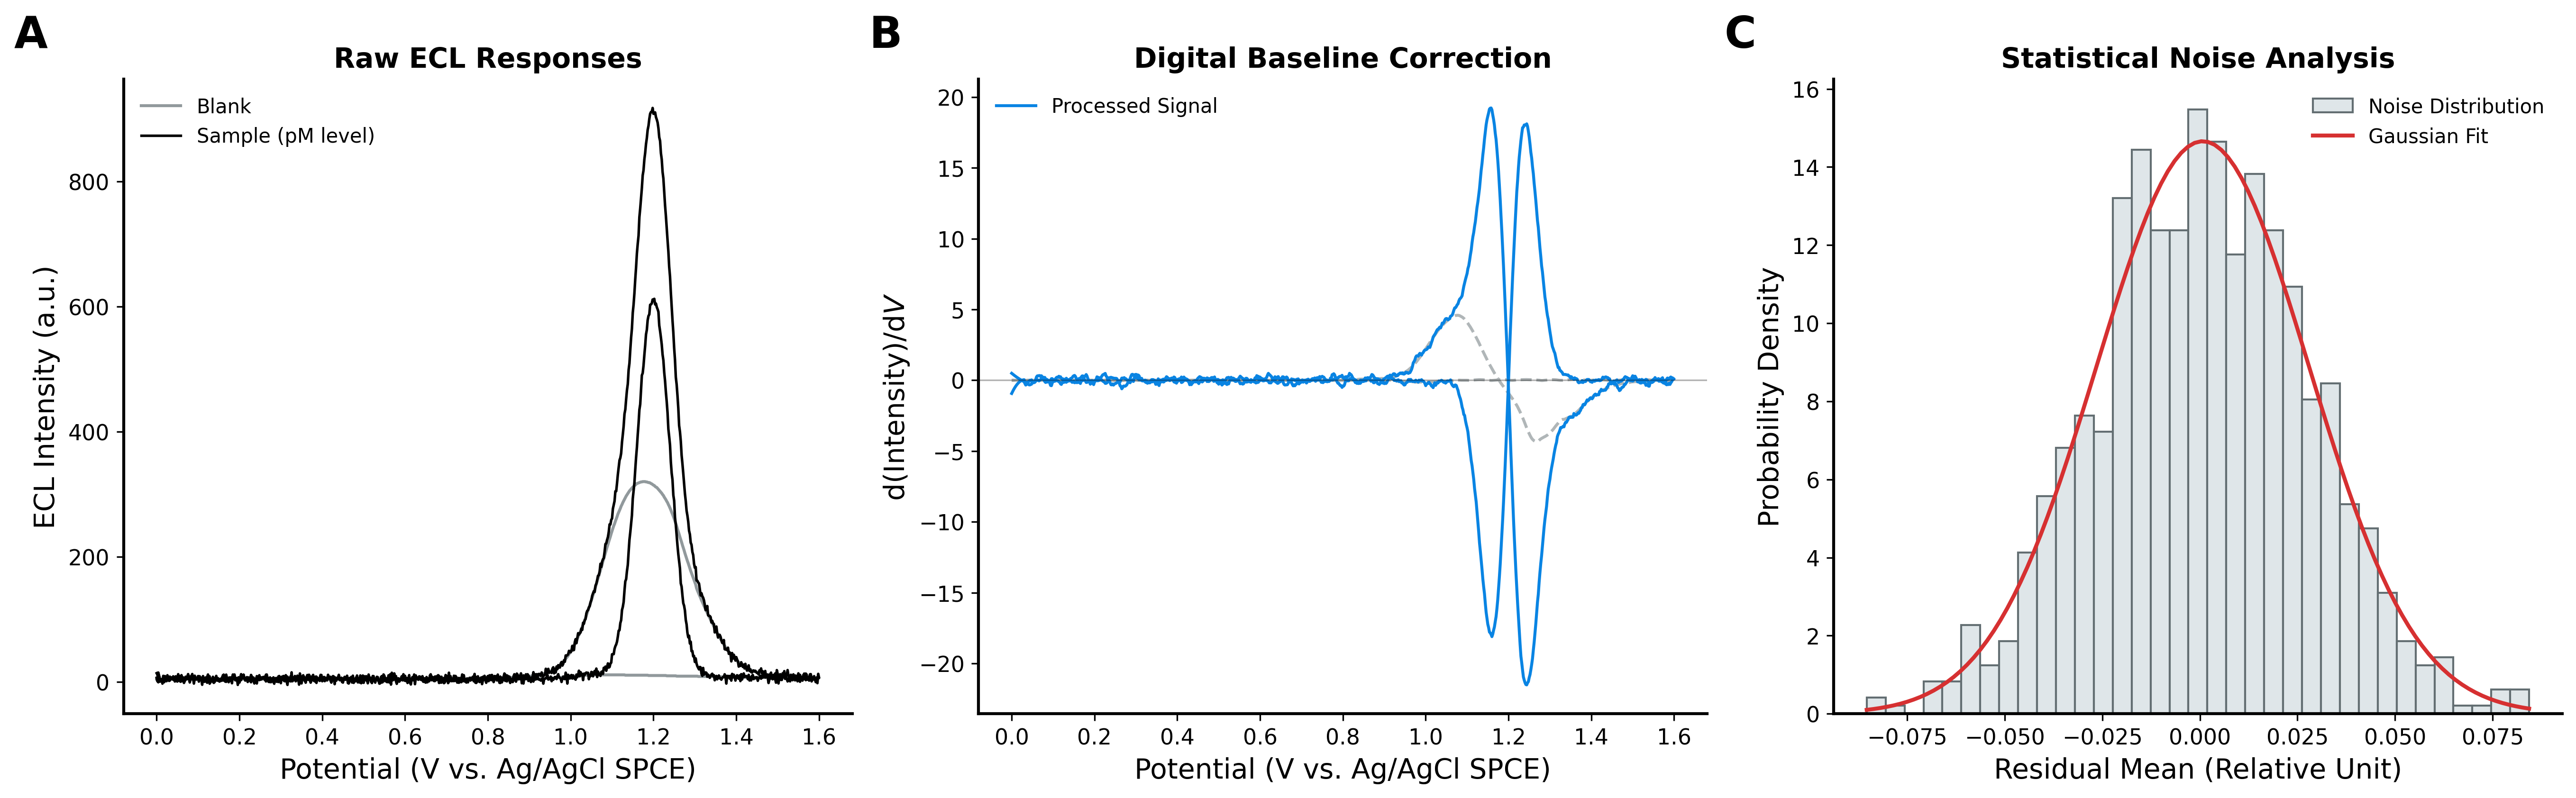

Publication figure created successfully.
Noise standard deviation: 2.7213e-02


In [24]:
import logging

from scipy.stats import norm

logging.getLogger("matplotlib.font_manager").setLevel(logging.ERROR)

plt.rcParams.update({
    "font.family": "serif",
    "font.serif": ["Times New Roman"],
    "font.size": 12,
    "axes.labelsize": 14,
    "axes.titlesize": 14,
    "xtick.labelsize": 11,
    "ytick.labelsize": 11,
    "legend.fontsize": 10,
    "axes.linewidth": 1.5,
    "figure.dpi": 300
})

CLR_BLANK = "#636e72"
CLR_SIGNAL = "#0984e3"
CLR_HIST = "#dfe6e9"
CLR_GAUSS = "#d63031"

v = BLANK["Voltage"].values
y_blank = BLANK["Blank"].values

synthetic_peak = 600 * np.exp(
    -((v - 1.2) ** 2) / (2 * 0.04 ** 2)
)

y_low_conc = (
    y_blank
    + synthetic_peak
    + np.random.normal(
        loc=0,
        scale=np.std(y_blank) * 0.05,
        size=len(v)
    )
)

y_blank_der = savgol_filter(
    y_blank,
    window_length=31,
    polyorder=3,
    deriv=1
)

y_low_der = savgol_filter(
    y_low_conc,
    window_length=31,
    polyorder=3,
    deriv=1
)

noise_pool = y_blank_der - np.mean(y_blank_der)

boot_means = [
    np.mean(
        y_blank_der
        + np.random.choice(
            noise_pool,
            size=len(y_blank_der),
            replace=True
        )
    )
    for _ in range(1000)
]

fig, axes = plt.subplots(
    1,
    3,
    figsize=(18, 5.5),
    constrained_layout=True
)

axes[0].plot(
    v,
    y_blank,
    color=CLR_BLANK,
    label="Blank",
    alpha=0.7
)

axes[0].plot(
    v,
    y_low_conc,
    color="black",
    label="Sample (pM level)",
    linewidth=1.3
)

axes[0].set_title(
    "Raw ECL Responses",
    fontweight="bold"
)

axes[0].set_xlabel(
    "Potential (V vs. Ag/AgCl SPCE)"
)

axes[0].set_ylabel(
    "ECL Intensity (a.u.)"
)

axes[0].legend(frameon=False)

axes[0].text(
    -0.15,
    1.05,
    "A",
    transform=axes[0].transAxes,
    fontsize=22,
    fontweight="bold"
)

axes[1].plot(
    v,
    y_blank_der,
    color=CLR_BLANK,
    linestyle="--",
    alpha=0.5
)

axes[1].plot(
    v,
    y_low_der,
    color=CLR_SIGNAL,
    label="Processed Signal"
)

axes[1].axhline(
    0,
    color="black",
    linewidth=0.8,
    alpha=0.3
)

axes[1].set_title(
    "Digital Baseline Correction",
    fontweight="bold"
)

axes[1].set_xlabel(
    "Potential (V vs. Ag/AgCl SPCE)"
)

axes[1].set_ylabel(
    "d(Intensity)/d$V$"
)

axes[1].legend(frameon=False)

axes[1].text(
    -0.15,
    1.05,
    "B",
    transform=axes[1].transAxes,
    fontsize=22,
    fontweight="bold"
)

axes[2].hist(
    boot_means,
    bins=35,
    color=CLR_HIST,
    edgecolor=CLR_BLANK,
    density=True,
    label="Noise Distribution"
)

mu, std = norm.fit(boot_means)

x_range = np.linspace(
    min(boot_means),
    max(boot_means),
    100
)

axes[2].plot(
    x_range,
    norm.pdf(x_range, mu, std),
    color=CLR_GAUSS,
    linewidth=2,
    label="Gaussian Fit"
)

axes[2].set_title(
    "Statistical Noise Analysis",
    fontweight="bold"
)

axes[2].set_xlabel(
    "Residual Mean (Relative Unit)"
)

axes[2].set_ylabel(
    "Probability Density"
)

axes[2].legend(frameon=False)

axes[2].text(
    -0.15,
    1.05,
    "C",
    transform=axes[2].transAxes,
    fontsize=22,
    fontweight="bold"
)

plt.savefig(
    "Final_ECL_SPCE_Publication_Figure.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

print("Publication figure created successfully.")
print(f"Noise standard deviation: {std:.4e}")